# Time Series

In [16]:
import pandas as pd
import numpy as np
import re

pd.options.display.max_columns = None

### Time series

A time series is a data set that tracks a sample over time. In particular, a time series allows one to see what factors influence certain variables from period to period. Time series analysis can be useful to see how a given asset, security, or economic variable changes over time.

Examples

- Financial Data (Company stocks)
- Natural Data (Rainfall measurement)
- Event Data (Covid)
- Medical Data (Heart rate monitoring)

Types of Operations done on Time Series

- Time Series Analysis
- Time Series Forecasting

In [17]:
google = pd.read_csv(r"D:\PandasNumpy\datasets\timeseries\google.csv")
google

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276
...,...,...,...,...,...,...,...
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600


In [18]:
google.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600
4470,2022-05-20,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100


In [19]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4471 non-null   object 
 1   Open       4471 non-null   float64
 2   High       4471 non-null   float64
 3   Low        4471 non-null   float64
 4   Close      4471 non-null   float64
 5   Adj Close  4471 non-null   float64
 6   Volume     4471 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 244.6+ KB


##### converting to datetime

In [20]:
google['Date'] = pd.to_datetime(google['Date'])

In [21]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[ns]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   float64       
 6   Volume     4471 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 244.6 KB


##### setting date as index

In [22]:
google.set_index('Date',inplace=True)

In [23]:
google.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [24]:
# fetch a specific date
google.loc['2021-12-30']

Open           2929.000000
High           2941.250000
Low            2915.169922
Close          2920.050049
Adj Close      2920.050049
Volume       648900.000000
Name: 2021-12-30 00:00:00, dtype: float64

#### fetch data based on year even if index is in 'yyyy-mm-dd' format

In [25]:
google.loc['2014'].tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-24,529.057495,530.303040,525.577026,527.322266,527.322266,705933
2014-12-26,527.322266,532.787231,525.866211,532.567810,532.567810,1040549
2014-12-29,530.732849,534.013855,528.559814,528.877991,528.877991,2278539
2014-12-30,526.644104,529.695740,525.686707,528.967712,528.967712,876299
2014-12-31,529.795471,531.141724,524.360352,524.958740,524.958740,1368246


#####  partial indexing -> select a particular year/month

In [26]:
google.loc['2021-12-30':'2022-01-19']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-12-30,2929.000000,2941.250000,2915.169922,2920.050049,2920.050049,648900
2021-12-31,2910.879883,2927.300049,2893.550049,2893.590088,2893.590088,864900
2022-01-03,2889.510010,2911.000000,2870.050049,2901.489990,2901.489990,1260700
2022-01-04,2911.010010,2932.199951,2876.322998,2888.330078,2888.330078,1146400
2022-01-05,2883.620117,2885.959961,2750.469971,2753.070068,2753.070068,2482100
2022-01-06,2749.949951,2793.719971,2735.270020,2751.020020,2751.020020,1452500
2022-01-07,2758.100098,2765.094971,2715.780029,2740.090088,2740.090088,970400
2022-01-10,2701.979980,2772.800049,2662.810059,2771.479980,2771.479980,1704800
2022-01-11,2763.610107,2806.590088,2736.270020,2800.350098,2800.350098,1175100


In [27]:
# interval of 3 days
google.loc['2021-12-30':'2022-01-19':3]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-12-30,2929.000000,2941.250000,2915.169922,2920.050049,2920.050049,648900
2022-01-04,2911.010010,2932.199951,2876.322998,2888.330078,2888.330078,1146400
2022-01-07,2758.100098,2765.094971,2715.780029,2740.090088,2740.090088,970400
2022-01-12,2831.090088,2856.284912,2822.239990,2832.959961,2832.959961,1182100
2022-01-18,2732.000000,2747.830078,2712.340088,2725.810059,2725.810059,1369100


### create year month-name and day-name

In [28]:
google['month_name'] = google.index.month_name()
google['weekday_name'] = google.index.day_name()
google['quarter'] = google.index.quarter

In [29]:
google.sample(5)

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2014-09-17,578.421936,585.911377,577.190308,583.168884,583.168884,1692835,September,Wednesday,3
2016-11-07,774.500000,785.190002,772.549988,782.520020,782.520020,1585100,November,Monday,4
2018-01-03,1064.310059,1086.290039,1063.209961,1082.479980,1082.479980,1430200,January,Wednesday,1
2012-10-08,379.079132,380.364288,375.666901,377.505005,377.505005,3931883,October,Monday,4
2016-10-17,779.799988,785.849976,777.500000,779.960022,779.960022,1093000,October,Monday,4


### challenge -> fetch info for a particular date every year -> limitation of timedelta

In [30]:
google.head()

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3


### <span class="pirk">Dateoffset</span>

In [31]:
pd.date_range(start='2005-1-6',end='2022-1-6',freq=pd.DateOffset(years=1))

DatetimeIndex(['2005-01-06', '2006-01-06', '2007-01-06', '2008-01-06',
               '2009-01-06', '2010-01-06', '2011-01-06', '2012-01-06',
               '2013-01-06', '2014-01-06', '2015-01-06', '2016-01-06',
               '2017-01-06', '2018-01-06', '2019-01-06', '2020-01-06',
               '2021-01-06', '2022-01-06'],
              dtype='datetime64[ns]', freq='<DateOffset: years=1>')

In [32]:
# 6th jan every year
google[google.index.isin(pd.date_range(start='2005-1-6',end='2022-1-6',freq=pd.DateOffset(years=1)))]

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


### plotting

C:\Users\Asus\AppData\Roaming\Python\Python39\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<Axes: xlabel='Date'>

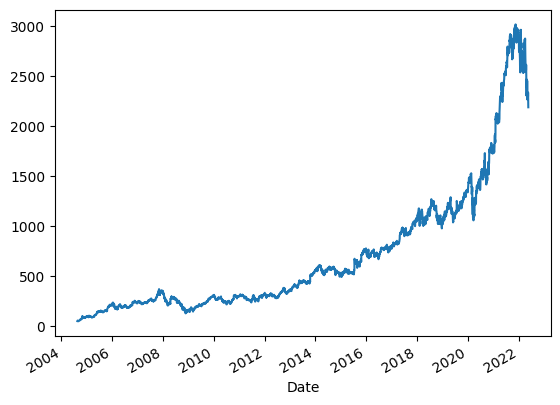

In [33]:
# viz a single col
google['Close'].plot()

### <span class="girk">plot for a particular year/month/week</span>

<Axes: xlabel='Date'>

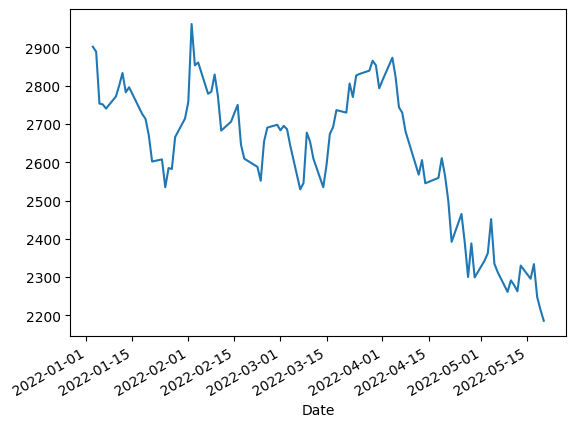

In [20]:
# for entire 2022
google.loc['2022']['Close'].plot()

<Axes: xlabel='Date'>

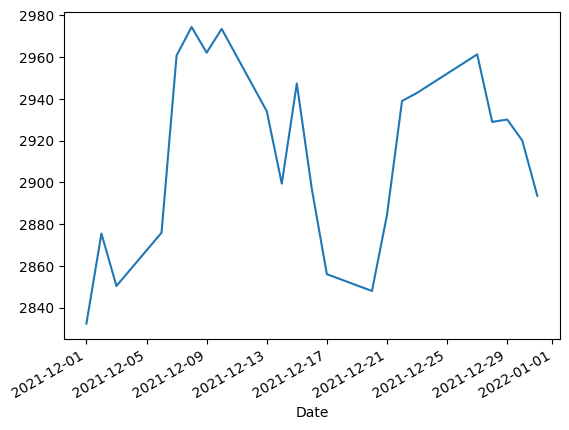

In [21]:
# for entire december of 2021
google.loc['2021-12']['Close'].plot()

#### trend using groupby

<Axes: xlabel='month_name'>

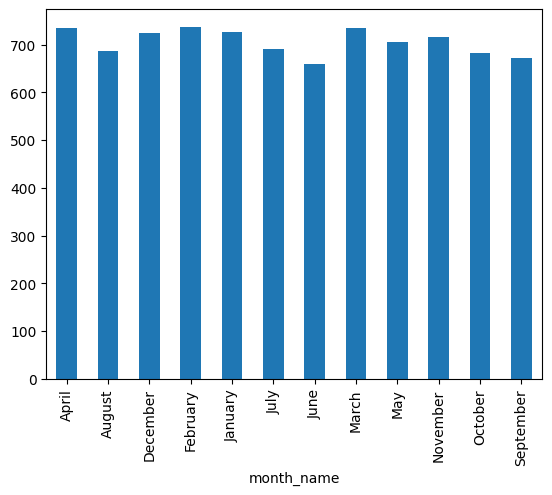

In [22]:
# monthly_trend
google.groupby('month_name')['Close'].mean().plot(kind='bar')

<Axes: xlabel='quarter'>

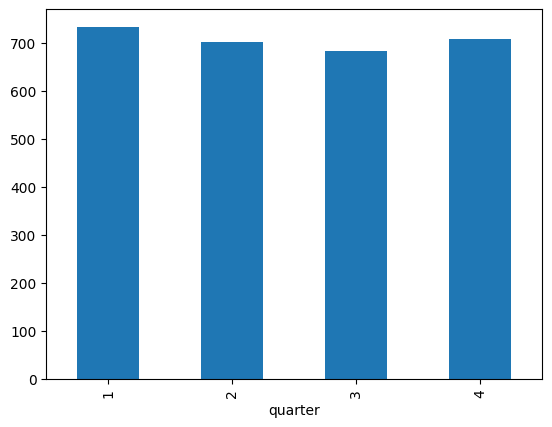

In [23]:
# quaterly trend
google.groupby('quarter')['Close'].mean().plot(kind='bar')

### frequency

In [24]:
google.index

DatetimeIndex(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
               '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30',
               '2004-08-31', '2004-09-01',
               ...
               '2022-05-09', '2022-05-10', '2022-05-11', '2022-05-12',
               '2022-05-13', '2022-05-16', '2022-05-17', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[ns]', name='Date', length=4471, freq=None)

### asfreq

In [25]:
# frequency as daily
google.asfreq('D')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897.0,August,Monday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100.0,May,Monday,2.0
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800.0,May,Tuesday,2.0
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100.0,May,Wednesday,2.0


In [30]:
# frequency as monthly end
google.asfreq('ME')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-31,50.958992,51.661362,50.889256,50.993862,50.993862,4941252.0,August,Tuesday,3.0
2004-09-30,64.707458,65.902977,64.259140,64.558022,64.558022,13823420.0,September,Thursday,3.0
2004-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-30,90.017593,91.158318,89.788452,90.650223,90.650223,15457723.0,November,Tuesday,4.0
2004-12-31,99.243011,99.566795,95.920464,96.035034,96.035034,15394487.0,December,Friday,4.0
...,...,...,...,...,...,...,...,...,...
2021-12-31,2910.879883,2927.300049,2893.550049,2893.590088,2893.590088,864900.0,December,Friday,4.0
2022-01-31,2683.959961,2716.870117,2645.479980,2713.969971,2713.969971,1702800.0,January,Monday,1.0
2022-02-28,2665.689941,2712.810059,2656.504883,2697.820068,2697.820068,1483800.0,February,Monday,1.0


In [27]:
# frequency as working day
google.asfreq('B')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897.0,August,Monday,3.0
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808.0,August,Tuesday,3.0
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276.0,August,Wednesday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100.0,May,Monday,2.0
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800.0,May,Tuesday,2.0
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100.0,May,Wednesday,2.0


In [29]:
# frequency as quarter
google.asfreq('QE')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-09-30,64.707458,65.902977,64.259140,64.558022,64.558022,13823420.0,September,Thursday,3.0
2004-12-31,99.243011,99.566795,95.920464,96.035034,96.035034,15394487.0,December,Friday,4.0
2005-03-31,88.642746,90.356323,88.488327,89.917969,89.917969,13587941.0,March,Thursday,1.0
2005-06-30,146.620438,148.906860,144.976593,146.525787,146.525787,30301955.0,June,Thursday,2.0
2005-09-30,156.523315,158.157181,155.561920,157.639130,157.639130,18371203.0,September,Friday,3.0
...,...,...,...,...,...,...,...,...,...
2021-03-31,2059.120117,2093.326904,2056.745117,2068.629883,2068.629883,1459900.0,March,Wednesday,1.0
2021-06-30,2513.071045,2516.000000,2495.149902,2506.320068,2506.320068,1200300.0,June,Wednesday,2.0
2021-09-30,2686.500000,2711.800049,2660.000000,2665.310059,2665.310059,1764700.0,September,Thursday,3.0


### forward fill -> peeche wali value aage aa jaayegi

In [507]:
# frequency as 6 Hours
google.asfreq('6H',method='ffill')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 06:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 12:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 18:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
...,...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2
2022-05-19 06:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2
2022-05-19 12:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2


### backward fill -> aage wali value  peeche chali jaayegi

In [508]:
google.asfreq('6H',method='bfill')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 06:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-19 12:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-19 18:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
...,...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2
2022-05-19 06:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100,May,Friday,2
2022-05-19 12:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100,May,Friday,2


## Resampling

Resampling involves changing the frequency of your time series observations.

Two types of resampling are:

- **Upsampling**: Where you increase the frequency of the samples, such as from minutes to seconds.



- **Downsampling**: Where you decrease the frequency of the samples, such as from days to months.

##### Upsampling

In [522]:
google['Close'].resample('12H').interpolate(method='spline',order=2)

Date
2004-08-19 00:00:00      49.982655
2004-08-19 12:00:00      52.309914
2004-08-20 00:00:00      53.952770
2004-08-20 12:00:00      55.591467
2004-08-21 00:00:00      56.388783
                          ...     
2022-05-18 00:00:00    2248.020020
2022-05-18 12:00:00    2365.166742
2022-05-19 00:00:00    2214.909912
2022-05-19 12:00:00    2065.798809
2022-05-20 00:00:00    2186.260010
Freq: 12H, Name: Close, Length: 12967, dtype: float64

<AxesSubplot:xlabel='Date'>

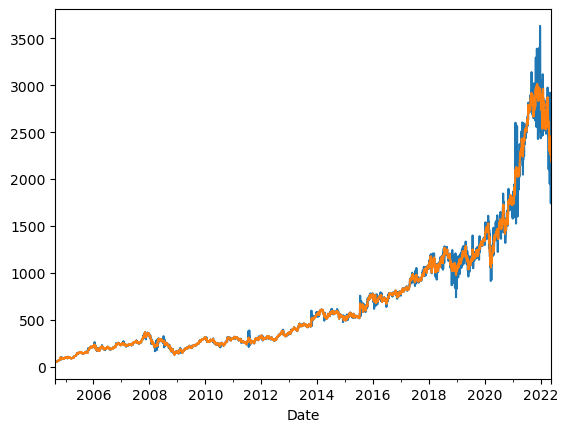

In [516]:
# Upsampling -> google data is changing from 1day to 12 hours
google['Close'].resample('12H').interpolate(method='spline',order=2).plot()
google['Close'].plot()

##### <span class="girk">Downsampling</span>

In [524]:
google['Close'].resample('3D').interpolate(method='spline',order=2)

Date
2004-08-19      49.982655
2004-08-22      51.986403
2004-08-25      52.802086
2004-08-28      52.472537
2004-08-31      50.993862
                 ...     
2022-05-08    2097.959994
2022-05-11    2279.219971
2022-05-14    2488.109788
2022-05-17    2334.030029
2022-05-20    2186.260010
Freq: 3D, Name: Close, Length: 2162, dtype: float64

<AxesSubplot:xlabel='Date'>

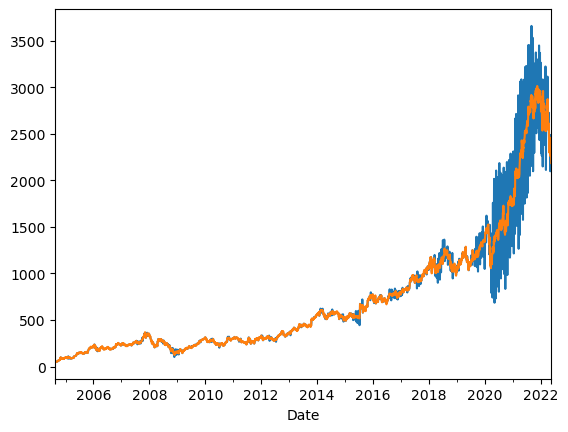

In [521]:
# downsampling --> changing from 1 day to 3 days
google['Close'].resample('3D').interpolate(method='spline',order=2).plot()
google['Close'].plot()

### Rolling Window(Smoothing)
Time series data in original format can be quite volatile, especially on smaller aggregation levels. The concept of rolling, or moving averages is a useful technique for smoothing time series data. 

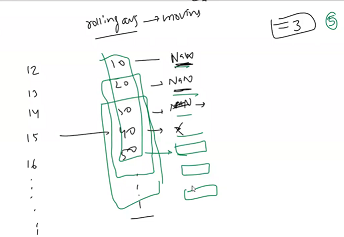

#### <span class="girk">In exponential weighted average we provide more weight to latest data</span>

<AxesSubplot:title={'center':'rolling'}, xlabel='Date'>

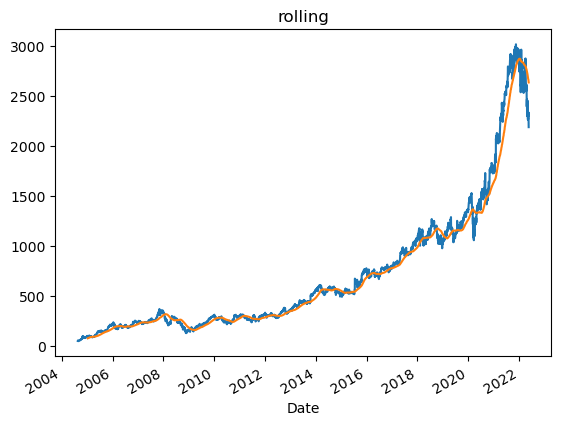

In [532]:
# Rolling window --> 100 days
google['Close'].plot()
google['Close'].rolling(100).mean().plot(title='rolling')

<AxesSubplot:title={'center':'ewm'}, xlabel='Date'>

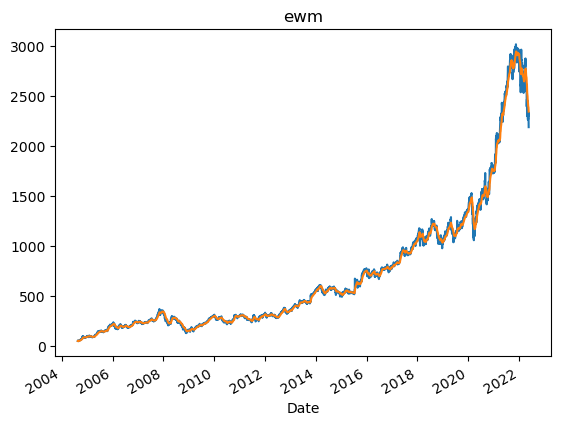

In [530]:
# exponential moving average --> 10 days
google['Close'].plot()
google['Close'].ewm(10).mean().plot(title='ewm')

<AxesSubplot:title={'center':'ewm'}, xlabel='Date'>

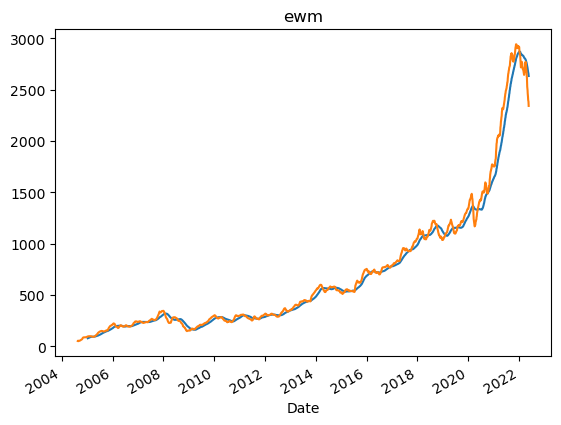

In [528]:
google['Close'].rolling(100).mean().plot(title='rolling')
google['Close'].ewm(10).mean().plot(title='ewm')

### Shifting
The shift() function is Pandas is used to, well, shift the entire series up or down by the desired number of periods.

In [535]:
login = pd.read_csv(r"D:\PandasNumpy\casestudy_pandas\timeseries\login.csv",header=None)
login

,0,1,2,3
0,1,466,2017-01-07 18:24:07,Unnamed: 3
1,2,466,2017-01-07 18:24:55,NaN
2,3,458,2017-01-07 18:25:18,NaN
3,4,458,2017-01-07 18:26:21,NaN
4,5,592,2017-01-07 19:09:59,NaN
...,...,...,...,...
2998,2999,1307,2018-01-04 10:48:28,183.82.121.201
2999,3000,1230,2018-01-04 11:22:00,47.247.147.114
3000,3001,1307,2018-01-04 13:13:44,183.82.121.201
3001,3002,1307,2018-01-04 13:13:45,183.82.121.201


In [536]:
df = login[[1,2]]

In [537]:
df.rename(columns={1:'user_id',2:'login_time'},inplace=True)
df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_10288\2326026427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={1:'user_id',2:'login_time'},inplace=True)


,user_id,login_time
0,466,2017-01-07 18:24:07
1,466,2017-01-07 18:24:55
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
4,592,2017-01-07 19:09:59


In [542]:
df['user_id'].value_counts()

413     222
458     208
492     162
882     140
592     122
       ... 
1043      1
1045      1
1047      1
1048      1
880       1
Name: user_id, Length: 433, dtype: int64

#### average return time for user 413

In [543]:
user_df = df[df['user_id'] == 413]
user_df.head()

,user_id,login_time
11,413,2017-01-09 12:29:25
12,413,2017-01-09 12:40:39
14,413,2017-01-09 14:08:04
33,413,2017-01-10 14:36:23
35,413,2017-01-10 15:22:45


In [544]:
user_df['login_time'] = pd.to_datetime(user_df['login_time'])

C:\Users\Asus\AppData\Local\Temp\ipykernel_10288\3275549453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['login_time'] = pd.to_datetime(user_df['login_time'])


In [545]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 222 entries, 11 to 2997
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     222 non-null    int64         
 1   login_time  222 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.2 KB


##### time duration between previous and next visit

In [547]:
user_df['shifted'] = user_df['login_time'].shift(1)

C:\Users\Asus\AppData\Local\Temp\ipykernel_10288\3509294578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['shifted'] = user_df['login_time'].shift(1)


In [548]:
user_df

,user_id,login_time,shifted
11,413,2017-01-09 12:29:25,NaT
12,413,2017-01-09 12:40:39,2017-01-09 12:29:25
14,413,2017-01-09 14:08:04,2017-01-09 12:40:39
33,413,2017-01-10 14:36:23,2017-01-09 14:08:04
35,413,2017-01-10 15:22:45,2017-01-10 14:36:23
...,...,...,...
2958,413,2017-12-29 18:20:32,2017-12-29 18:19:48
2963,413,2017-12-30 13:41:21,2017-12-29 18:20:32
2974,413,2018-01-01 15:16:25,2017-12-30 13:41:21
2982,413,2018-01-02 18:15:45,2018-01-01 15:16:25


In [554]:
user_df['login_time'] - user_df['shifted']

11                 NaT
12     0 days 00:11:14
14     0 days 01:27:25
33     1 days 00:28:19
35     0 days 00:46:22
             ...      
2958   0 days 00:00:44
2963   0 days 19:20:49
2974   2 days 01:35:04
2982   1 days 02:59:20
2997   1 days 16:27:58
Length: 222, dtype: timedelta64[ns]

In [555]:
(user_df['login_time'] - user_df['shifted']).mean()

Timedelta('1 days 15:05:13.384615384')

In [553]:
user_df

,user_id,login_time,shifted
11,413,2017-01-09 12:29:25,NaT
12,413,2017-01-09 12:40:39,2017-01-09 12:29:25
14,413,2017-01-09 14:08:04,2017-01-09 12:40:39
33,413,2017-01-10 14:36:23,2017-01-09 14:08:04
35,413,2017-01-10 15:22:45,2017-01-10 14:36:23
...,...,...,...
2958,413,2017-12-29 18:20:32,2017-12-29 18:19:48
2963,413,2017-12-30 13:41:21,2017-12-29 18:20:32
2974,413,2018-01-01 15:16:25,2017-12-30 13:41:21
2982,413,2018-01-02 18:15:45,2018-01-01 15:16:25


In [556]:
google.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'month_name',
       'weekday_name', 'quarter'],
      dtype='object')

___
___
___

# Working with Textual data :

In [35]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import re

In [36]:
imdb = pd.read_csv(r"D:\PandasNumpy\datasets\nlp_pandas\IMDB Dataset.csv")
imdb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [188]:
imdb = imdb.sample(500)
imdb.reset_index(inplace=True,drop=True)
imdb.shape

(500, 2)

In [189]:
imdb.head()

,review,sentiment
0,I guess I was prepared after all the years of ...,negative
1,I bought this video on a throw-out table at th...,negative
2,Not all movies should have that predictable en...,positive
3,Slashers.....well if you like horrors its defi...,negative
4,I have seen many - possibly too many straight-...,negative


In [190]:
imdb.isnull().sum()

review       0
sentiment    0
dtype: int64

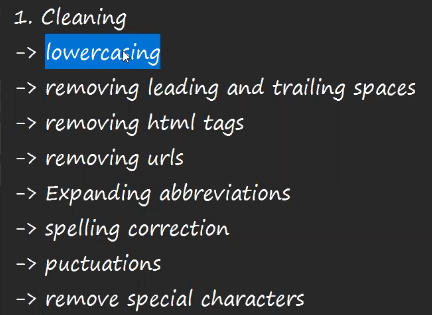

##### dropping duplicates

In [191]:
imdb.drop_duplicates(inplace=True)

In [192]:
imdb.shape

(500, 2)

In [193]:
imdb['review'][0]

"I guess I was prepared after all the years of hearing about it. First heard about it from Siskel and Ebert. When they said Divine ate excrement, I had to look it up. Then a friend told me about it in 1991. She said also that her parents saw it when it first came out and that her mom almost dumped her dad over it! So by the time I caught Pink Flamingos on Sundance today, I was prepared. For the most part.<br /><br />I still couldn't help but be surprised by the anal close-ups and the blowjob scene. That said, the only characters I sympathized with were Edie and the egg man. Her crying scene early in the film, though over something frivolous to normal people, actually makes me sad. Though she sure wasn't pretty, she had a cute voice. I was happy for her and the egg man, and they actually touched me.<br /><br />On the other hand, the acting in this poverty-level production was not good. And as for the script, just how does John Waters come up with this stuff? Well, at least it's differen

##### lower case

In [194]:
imdb['review'] = imdb['review'].str.lower()
imdb

,review,sentiment
0,i guess i was prepared after all the years of ...,negative
1,i bought this video on a throw-out table at th...,negative
2,not all movies should have that predictable en...,positive
3,slashers.....well if you like horrors its defi...,negative
4,i have seen many - possibly too many straight-...,negative
...,...,...
495,how on earth were these guys given funds to ma...,negative
496,i saw this film at the 2004 toronto internatio...,positive
497,one of our all time family favorites. when we ...,positive
498,the untold... is one of the worst films i ever...,negative


##### remove whitespaces

In [195]:
imdb['review'] = imdb['review'].str.strip()
imdb['review']

0      i guess i was prepared after all the years of ...
1      i bought this video on a throw-out table at th...
2      not all movies should have that predictable en...
3      slashers.....well if you like horrors its defi...
4      i have seen many - possibly too many straight-...
                             ...                        
495    how on earth were these guys given funds to ma...
496    i saw this film at the 2004 toronto internatio...
497    one of our all time family favorites. when we ...
498    the untold... is one of the worst films i ever...
499    i am so glad when i watch in every time the mo...
Name: review, Length: 500, dtype: object

#####  remove html tags

In [196]:
imdb['review'] = imdb['review'].str.replace(r'<.*?>','')
imdb['review']

C:\Users\Asus\AppData\Local\Temp\ipykernel_18992\731065964.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  imdb['review'] = imdb['review'].str.replace(r'<.*?>','')


0      i guess i was prepared after all the years of ...
1      i bought this video on a throw-out table at th...
2      not all movies should have that predictable en...
3      slashers.....well if you like horrors its defi...
4      i have seen many - possibly too many straight-...
                             ...                        
495    how on earth were these guys given funds to ma...
496    i saw this film at the 2004 toronto internatio...
497    one of our all time family favorites. when we ...
498    the untold... is one of the worst films i ever...
499    i am so glad when i watch in every time the mo...
Name: review, Length: 500, dtype: object

##### removing urls:

In [197]:
imdb[imdb['review'].str.contains('www\.')]['review']

71     love trap is not a short, it's quite obviously...
416    i swore i would never allow myself to devolve ...
Name: review, dtype: object

In [198]:
# http://campusx.in or www.campusx.in or www.campusx.co.in

# regular expression:

def remove_url(data):
    data = re.sub(r'https?://\S+|www\.\S+','',data)
    return data

In [199]:
remove_url('https://www.campusx.com is the best website')

' is the best website'

In [200]:
remove_url('www.kaggle.in is the best website')

' is the best website'

In [201]:
# doing without regular expressions
imdb['review'] = imdb['review'].str.replace(r'https?://\S+|www\.\S+','')
imdb['review']

C:\Users\Asus\AppData\Local\Temp\ipykernel_18992\3005996104.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  imdb['review'] = imdb['review'].str.replace(r'https?://\S+|www\.\S+','')


0      i guess i was prepared after all the years of ...
1      i bought this video on a throw-out table at th...
2      not all movies should have that predictable en...
3      slashers.....well if you like horrors its defi...
4      i have seen many - possibly too many straight-...
                             ...                        
495    how on earth were these guys given funds to ma...
496    i saw this film at the 2004 toronto internatio...
497    one of our all time family favorites. when we ...
498    the untold... is one of the worst films i ever...
499    i am so glad when i watch in every time the mo...
Name: review, Length: 500, dtype: object

In [202]:
# check if any url is present or not
imdb[imdb['review'].str.contains(r'https?://\S+|www\.\S+')]['review']

Series([], Name: review, dtype: object)

##### expanding abbvr

In [203]:
def remove_abb(data):
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    
    return data

In [204]:
imdb['review'] = imdb['review'].apply(remove_abb)

In [205]:
imdb['review']

0      i guess i was prepared after all the years of ...
1      i bought this video on a throw-out table at th...
2      not all movies should have that predictable en...
3      slashers.....well if you like horrors its defi...
4      i have seen many - possibly too many straight-...
                             ...                        
495    how on earth were these guys given funds to ma...
496    i saw this film at the 2004 toronto internatio...
497    one of our all time family favorites. when we ...
498    the untold... is one of the worst films i ever...
499    i am so glad when i watch in every time the mo...
Name: review, Length: 500, dtype: object

##### spelling correction

In [206]:
from textblob import TextBlob

text = "hi I can drve at nigt"
TextBlob(text).correct().string

'hi I can drove at night'

In [207]:
def spelling_correction(text):
    return TextBlob(text).correct().string

In [208]:
imdb.loc[:4,'review'].apply(spelling_correction)
# will take tooooooooo much time

0    i guess i was prepared after all the years of ...
1    i bought this video on a throw-out table at th...
2    not all moves should have that predictable end...
3    lashes.....well if you like horrors its defini...
4    i have seen many - possibly too many straight-...
Name: review, dtype: object

In [209]:
imdb['review'] = imdb['review'].apply(spelling_correction)

##### remove punctuation mark

In [210]:
import string

In [211]:
string.punctuation
# '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [212]:
def remove_puctuation(text):
    
    for i in string.punctuation:
        if i in text:
            text = text.replace(i,'')
            
    return text

In [213]:
imdb['review'] = imdb['review'].apply(remove_puctuation)
imdb['review'].head()

0    i guess i was prepared after all the years of ...
1    i bought this video on a throwout table at the...
2    not all moves should have that predictable end...
3    lasheswell if you like horrors its definitely ...
4    i have seen many  possibly too many straightto...
Name: review, dtype: object

##### remove special characters

[^\w\s']

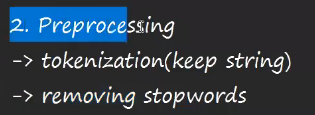

In [214]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [215]:
from nltk.tokenize import word_tokenize

In [216]:
imdb['tokenized_review'] = imdb['review'].apply(word_tokenize)
imdb

,review,sentiment,tokenized_review
0,i guess i was prepared after all the years of ...,negative,"[i, guess, i, was, prepared, after, all, the, ..."
1,i bought this video on a throwout table at the...,negative,"[i, bought, this, video, on, a, throwout, tabl..."
2,not all moves should have that predictable end...,positive,"[not, all, moves, should, have, that, predicta..."
3,lasheswell if you like horrors its definitely ...,negative,"[lasheswell, if, you, like, horrors, its, defi..."
4,i have seen many possibly too many straightto...,negative,"[i, have, seen, many, possibly, too, many, str..."
...,...,...,...
495,how on earth were these guns given funds to ma...,negative,"[how, on, earth, were, these, guns, given, fun..."
496,i saw this film at the 2004 toronto internatio...,positive,"[i, saw, this, film, at, the, 2004, toronto, i..."
497,one of our all time family favorites when we n...,positive,"[one, of, our, all, time, family, favorites, w..."
498,the untold is one of the worst films i ever sa...,negative,"[the, untold, is, one, of, the, worst, films, ..."


### stop words removal

In [217]:
from nltk.corpus import stopwords

In [218]:
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [219]:
def remove_stopwords(text):
    
    L = []
    for word in text:
        if word not in stopwords.words('english'):
            L.append(word)
            
    return L

In [220]:
imdb['tokenized_review'] = imdb['tokenized_review'].apply(remove_stopwords)

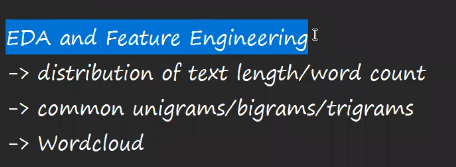

In [221]:
imdb

,review,sentiment,tokenized_review
0,i guess i was prepared after all the years of ...,negative,"[guess, prepared, years, hearing, first, heard..."
1,i bought this video on a throwout table at the...,negative,"[bought, video, throwout, table, video, store,..."
2,not all moves should have that predictable end...,positive,"[moves, predictable, ending, use, great, see, ..."
3,lasheswell if you like horrors its definitely ...,negative,"[lasheswell, like, horrors, definitely, one, s..."
4,i have seen many possibly too many straightto...,negative,"[seen, many, possibly, many, straighttovideo, ..."
...,...,...,...
495,how on earth were these guns given funds to ma...,negative,"[earth, guns, given, funds, make, movie, lack,..."
496,i saw this film at the 2004 toronto internatio...,positive,"[saw, film, 2004, toronto, international, film..."
497,one of our all time family favorites when we n...,positive,"[one, time, family, favorites, need, laughwe, ..."
498,the untold is one of the worst films i ever sa...,negative,"[untold, one, worst, films, ever, saw, story, ..."


In [222]:
imdb.to_csv('imdb_list_token_removed_stopwords.csv',index=False)

#### joining after removing stop words

In [223]:
imdb['review'] = imdb['tokenized_review'].apply(lambda x:" ".join(x))

In [224]:
imdb

,review,sentiment,tokenized_review
0,guess prepared years hearing first heard siste...,negative,"[guess, prepared, years, hearing, first, heard..."
1,bought video throwout table video store expect...,negative,"[bought, video, throwout, table, video, store,..."
2,moves predictable ending use great see moves r...,positive,"[moves, predictable, ending, use, great, see, ..."
3,lasheswell like horrors definitely one see oth...,negative,"[lasheswell, like, horrors, definitely, one, s..."
4,seen many possibly many straighttovideo budget...,negative,"[seen, many, possibly, many, straighttovideo, ..."
...,...,...,...
495,earth guns given funds make movie lack script ...,negative,"[earth, guns, given, funds, make, movie, lack,..."
496,saw film 2004 toronto international film festi...,positive,"[saw, film, 2004, toronto, international, film..."
497,one time family favorites need laughwe put one...,positive,"[one, time, family, favorites, need, laughwe, ..."
498,untold one worst films ever saw story really s...,negative,"[untold, one, worst, films, ever, saw, story, ..."


In [225]:
imdb.to_csv('imdb_list_together_removed_stopwords.csv',index=False)

### EDA

-  charcater length of each review


- total words in each review

In [226]:
imdb['char_len'] = imdb['review'].str.len()
imdb['word_len'] = imdb['tokenized_review'].apply(len)

In [227]:
imdb

,review,sentiment,tokenized_review,char_len,word_len
0,guess prepared years hearing first heard siste...,negative,"[guess, prepared, years, hearing, first, heard...",547,84
1,bought video throwout table video store expect...,negative,"[bought, video, throwout, table, video, store,...",687,95
2,moves predictable ending use great see moves r...,positive,"[moves, predictable, ending, use, great, see, ...",425,59
3,lasheswell like horrors definitely one see oth...,negative,"[lasheswell, like, horrors, definitely, one, s...",580,88
4,seen many possibly many straighttovideo budget...,negative,"[seen, many, possibly, many, straighttovideo, ...",567,83
...,...,...,...,...,...
495,earth guns given funds make movie lack script ...,negative,"[earth, guns, given, funds, make, movie, lack,...",380,60
496,saw film 2004 toronto international film festi...,positive,"[saw, film, 2004, toronto, international, film...",1632,222
497,one time family favorites need laughwe put one...,positive,"[one, time, family, favorites, need, laughwe, ...",379,61
498,untold one worst films ever saw story really s...,negative,"[untold, one, worst, films, ever, saw, story, ...",431,69


##### sentiment is positive

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='char_len', ylabel='Density'>

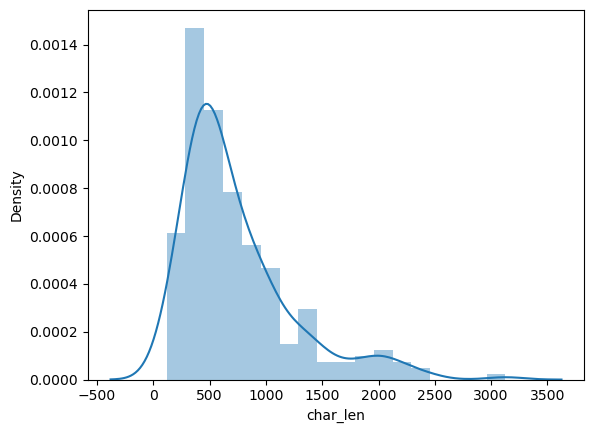

In [228]:
sns.distplot(imdb[imdb['sentiment'] == 'positive']['char_len'])

##### sentiment is negative

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='char_len', ylabel='Density'>

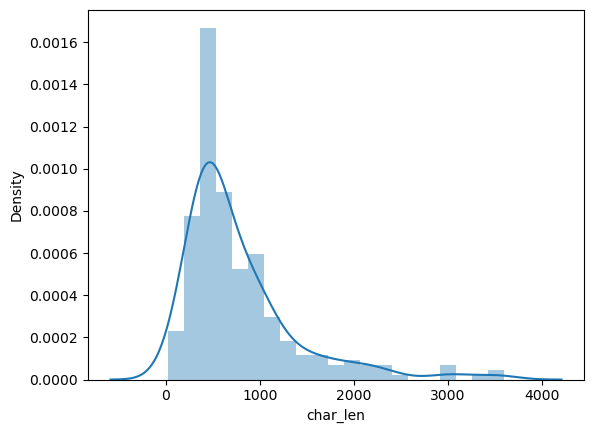

In [229]:
sns.distplot(imdb[imdb['sentiment'] == 'negative']['char_len'])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='char_len', ylabel='Density'>

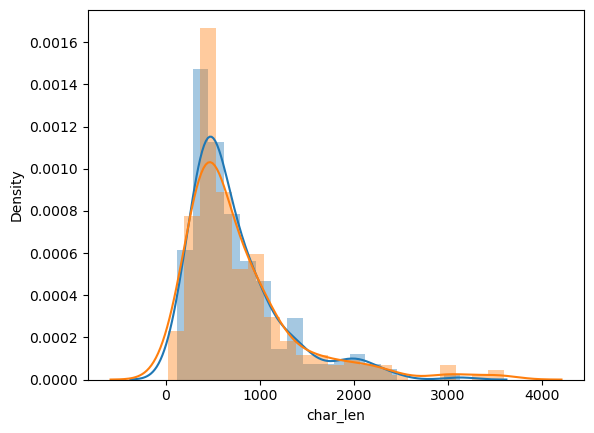

In [230]:
sns.distplot(imdb[imdb['sentiment'] == 'positive']['char_len'])
sns.distplot(imdb[imdb['sentiment'] == 'negative']['char_len'])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='word_len', ylabel='Density'>

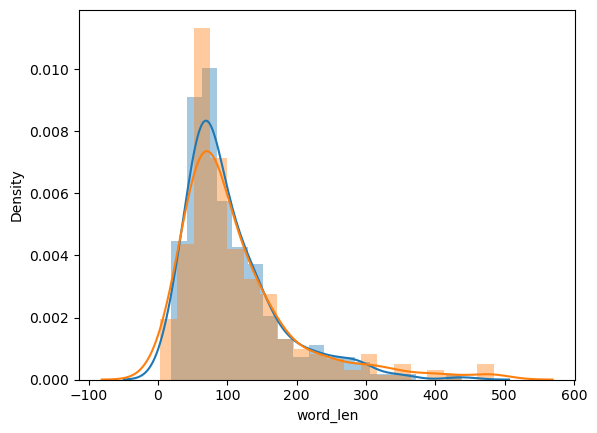

In [231]:
sns.distplot(imdb[imdb['sentiment'] == 'positive']['word_len'])
sns.distplot(imdb[imdb['sentiment'] == 'negative']['word_len'])

### ngrams:

- __unigrams__ - single word


- __bigram__ - combination of 2 words


- __trigrams__ - pair of 3 words

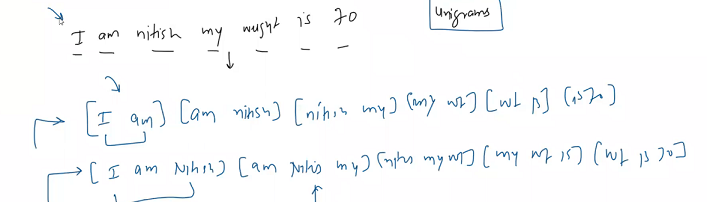

#### creating bi-grams

In [232]:
from nltk import ngrams

In [233]:
pd.Series(ngrams(imdb['tokenized_review'].sum(),2)).value_counts()

(I, seen)            27
(waste, time)        24
(see, movie)         23
(I, would)           23
(ever, seen)         22
                     ..
(show, 25)            1
(25, years)           1
(years, songs)        1
(show, album)         1
(brilliant, life)     1
Length: 49250, dtype: int64

### word cloud

In [234]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

##### positive word cloud

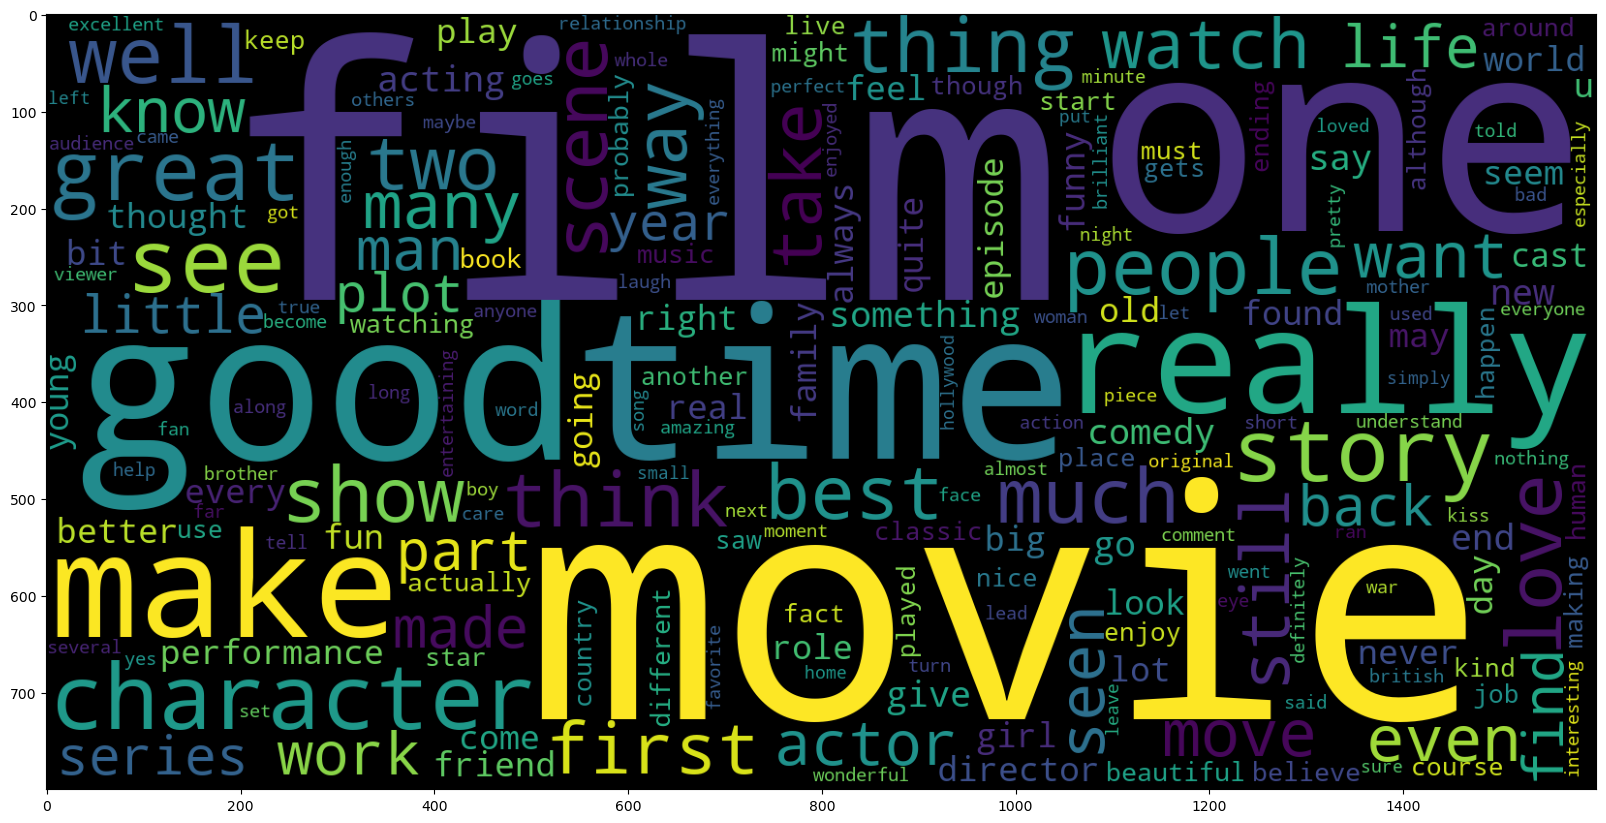

In [235]:
plt.figure(figsize = (20,20)) # Positive Review Text
wc = WordCloud(width = 1600 , height = 800).generate(" ".join(imdb[imdb['sentiment'] == 'positive']['review']))
plt.imshow(wc)

##### negative word cloud

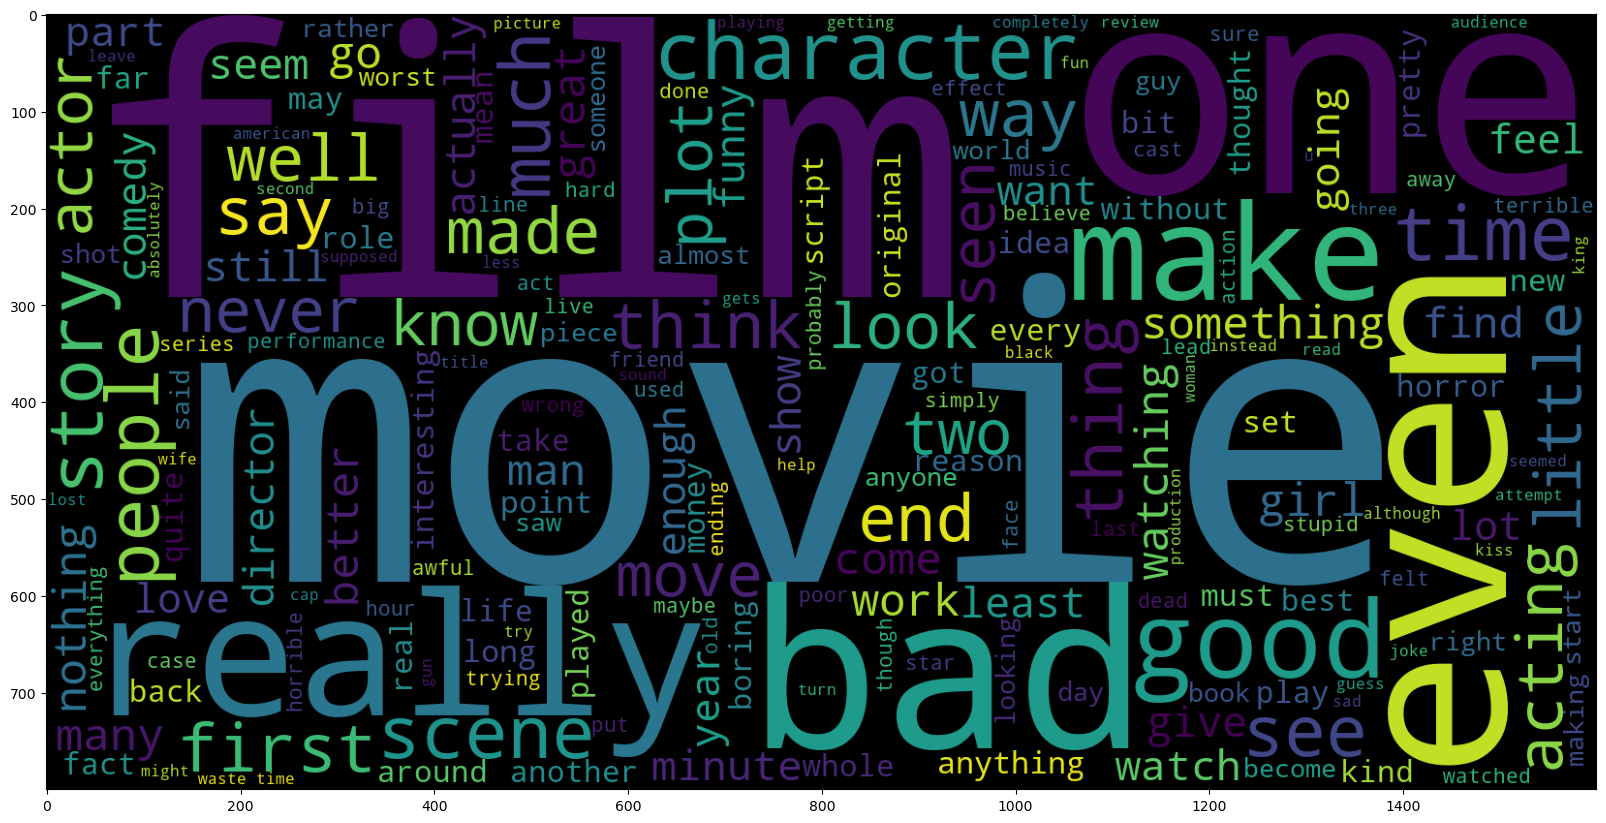

In [236]:
plt.figure(figsize = (20,20)) # Positive Review Text
wc = WordCloud(width = 1600 , height = 800).generate(" ".join(imdb[imdb['sentiment'] == 'negative']['review']))
plt.imshow(wc)

## Vectorisation : 

### Bag of words - converting data into numbers

In [237]:
from sklearn.feature_extraction.text import CountVectorizer

##### 200 here means we are taking top 200 words
##### (1,1) is unigram

In [238]:
count_vectorizer = CountVectorizer(max_features=200,ngram_range=(1,1))
bag_of_words = count_vectorizer.fit_transform(imdb['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(),columns = count_vectorizer.get_feature_names())

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [239]:
bag_of_words

,acting,action,actors,actually,almost,also,although,always,another,anyone,...,woman,work,world,worst,worth,would,year,years,yet,young
0,1,0,0,2,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,1,3,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,2,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


##### bigram - (2,2)

In [240]:
count_vectorizer = CountVectorizer(max_features=200,ngram_range=(2,2))
bag_of_words = count_vectorizer.fit_transform(imdb['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(),columns = count_vectorizer.get_feature_names())

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [241]:
bag_of_words

,acting bad,anything else,back day,bad acting,bad movie,believe film,best show,better davis,big budget,black white,...,would better,would like,would recommend,would say,wresting girl,year old,years ago,years later,you would,young girl
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


##### trigram - (3,3)

In [242]:
count_vectorizer = CountVectorizer(max_features=300,ngram_range=(3,3))
bag_of_words = count_vectorizer.fit_transform(imdb['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(),columns = count_vectorizer.get_feature_names())

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [243]:
bag_of_words

,10 items less,23 business days,agreeing terms laid,alpha male male,also provides movie,anyone associated movie,assault predict 13,back day ask,backwater valley exorcise,bad acting bad,...,worst movie ever,would like buy,would like see,would much better,would recommend movie,would say go,write english html,wrong side tracks,year old boy,you would see
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### top of unigram, bigram, trigram - (1,3)

In [244]:
count_vectorizer = CountVectorizer(max_features=200,ngram_range=(1,3))
bag_of_words = count_vectorizer.fit_transform(imdb['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(),columns = count_vectorizer.get_feature_names())

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [245]:
bag_of_words

,acting,action,actors,actually,almost,also,although,always,another,anyone,...,woman,work,world,worst,worth,would,year,years,yet,young
0,1,0,0,2,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,1,3,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,2,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


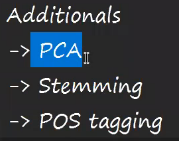

### Applying PCA to reducce dimensions

In [246]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(bag_of_words.values)

In [247]:
pca_result.shape

(500, 2)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

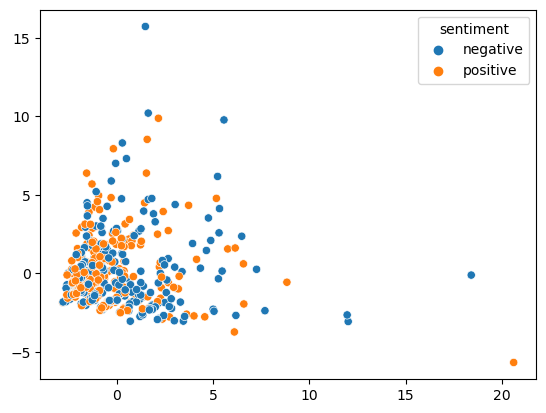

In [248]:
sns.scatterplot(pca_result[:,0],pca_result[:,1],hue=imdb['sentiment'])